# Liver cell identity and probe feasibility in MERFISH

Which genes should be measured in a spatial liver assay so that cell identities and their expression programs remain interpretable? The source snRNA-seq provides broad cell-state coverage, while spatial references add tissue context; the experiment compares a source-only panel with a panel informed by both kinds of biological evidence before reading out MERFISH.

This notebook trains source and spatial-reference models from the downloaded H5AD files, combines their in-memory rankings, and evaluates the current SMITH panels directly on held-out MERFISH biology. Figure 6f-g then visualizes completed manuscript-scale probe-design outputs; the hosted page does not rerun those hours-long external backends.

## Download the source data

```bash
python scripts/download_tutorial_data.py --case 05_agent --data-root data/tutorials
```

The four H5AD files used for SMITH training and MERFISH evaluation are real liver source, target and spatial-reference inputs. The notebook creates its panel rankings and shared-gene objects in memory; it does not load a prior panel or evaluation file.

## Load raw modalities and define the biological measurement space

In [ ]:
from pathlib import Path
import os, sys

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "reproducibility").is_dir() and (candidate / "scripts").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the SMITH repository root")
sys.path.insert(0, str(ROOT))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from IPython.display import display
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
from reproducibility.workflows.common import run_smith, write_json, write_panel_genes
from smith_agent.benchmarking import (
    prepare_agent_adata,
    cell_type_evaluation_loaded,
    spatial_coordinate_evaluation_loaded,
    mean_expression_loaded,
)
from smith_agent.panel_rank_aggregation import (
    aggregate_reference_panel_ranks_loaded,
    tune_reference_aggregation_loaded,
)
from smith_agent.config import load_agent_config
from smith_agent.registry import load_registries
from reproducibility.workflows.agent.plot_figure6 import _draw_violin_panel
from reproducibility.workflows.figure_style import configure
configure()

def resolve_repo_path(value):
    path = Path(value)
    return path if path.is_absolute() else ROOT / path

DATA_ROOT = resolve_repo_path(os.environ.get("SMITH_TUTORIAL_DATA", "data/tutorials"))
CASE_OUTPUT = resolve_repo_path(os.environ.get("SMITH_TUTORIAL_OUTPUT", "outputs/tutorials")) / "agent"
FIGURE_DATA = CASE_OUTPUT / "figure_data"
EPOCHS = int(os.environ.get("SMITH_TUTORIAL_EPOCHS", 30))
DEVICE = os.environ.get("SMITH_TUTORIAL_DEVICE", 'cpu')
MAX_CELLS = int(os.environ.get("SMITH_TUTORIAL_MAX_CELLS", "3000"))
FIGURE_DATA.mkdir(parents=True, exist_ok=True)


In [ ]:
relative_inputs = [
    "agent/liver_merfish/adata_healthy_nucseq.h5ad",
    "agent/liver_merfish/adata_healthy_merfish.h5ad",
    "agent/references/PSC011_C1_visium.h5ad",
    "agent/references/WSSS_F_IMMsp9838712_visium.h5ad",
]
paths = {name: DATA_ROOT / name for name in relative_inputs}
for path in paths.values():
    if not path.is_file():
        raise FileNotFoundError(path)

# These are the downloaded source H5ADs. Shared-gene and label filtering happen
# below in memory; no prepared_data or previous panel is used as an input.
source_raw, merfish, ref_a_raw, ref_b_raw = [ad.read_h5ad(paths[name]) for name in relative_inputs]
gene_universe = list(dict.fromkeys(str(gene).upper() for gene in merfish.var_names if str(gene).strip()))
source = prepare_agent_adata(source_raw, gene_universe, max_cells=MAX_CELLS, seed=1)
ref_a = prepare_agent_adata(ref_a_raw, gene_universe, require_spatial=True, max_cells=MAX_CELLS, seed=1)
ref_b = prepare_agent_adata(ref_b_raw, gene_universe, require_spatial=True, max_cells=MAX_CELLS, seed=1)
merfish_indices = np.arange(merfish.n_obs)
tuning_index, evaluation_index = train_test_split(
    merfish_indices, test_size=0.5, random_state=41, stratify=merfish.obs["Cell_Type"].astype(str),
)
merfish_tuning = merfish[np.sort(tuning_index)].copy()
merfish_evaluation = merfish[np.sort(evaluation_index)].copy()


## Execute the Agent plan: train source and reference SMITH models

In [ ]:
# The Agent plan is resolved from the package registries, then executed on these objects.
agent_config = load_agent_config(ROOT / "configs/agent/agent.yaml")
agent_registries = load_registries(agent_config)
agent_plan = [
    {"skill": "task_intake", "tool": "resolve_dataset_context", "status": "completed"},
    {"skill": "panel_optimization", "tool": "run_smith_selection", "status": "completed"},
    {"skill": "reference_retrieval", "tool": "aggregate_reference_panel_ranks", "status": "completed"},
    {"skill": "evaluation", "tool": "evaluate_cross_dataset_panel", "status": "completed"},
    {"skill": "feasibility_filtering", "tool": "visualize_reference_probe_results", "status": "reference"},
]

source_run = run_smith(
    adata_file=None, adata=source, output_dir=CASE_OUTPUT / "runs/seed_1/source_smith",
    tasks="recon,cls", task_name="liver_source_seed1", panel_size=128,
    epochs=EPOCHS, device=DEVICE, seed=1, batch_size=128,
    sampling_strategy="celltype", force=True, include_in_memory=True,
)
reference_runs = []
for name, reference in (("PSC011_C1_visium", ref_a), ("WSSS_F_IMMsp9838712", ref_b)):
    reference_runs.append(run_smith(
        adata_file=None, adata=reference,
        output_dir=CASE_OUTPUT / "runs/seed_1/reference_smith" / name,
        tasks="recon,cls,standard_coordination", task_name=f"{name}_seed1",
        panel_size=128, epochs=EPOCHS, device=DEVICE, seed=1, batch_size=128,
        sampling_strategy="celltype_spatial", force=True, include_in_memory=True,
    ))
aggregation = aggregate_reference_panel_ranks_loaded(
    source_run["ranking_frame"], [item["ranking_frame"] for item in reference_runs],
    panel_size=128, source_weight=0.5, reference_weight=0.5,
    min_reference_support=2, restrict_gene_symbols=gene_universe, gene_universe="source",
)


### SMITH-Agent workflow stages

In [ ]:
figure, axis = plt.subplots(figsize=(5.6, 1.15), facecolor="white")
axis.axis("off")
for index, step in enumerate(agent_plan):
    x = 0.02 + index * 0.245
    color = "#2f78bd" if step["status"] == "completed" else "#b7791f"
    axis.text(x, 0.62, step["skill"].replace("_", "\n"), ha="left", va="center", fontsize=8, color=color, weight="bold")
    if index < len(agent_plan) - 1:
        axis.annotate("", xy=(x + 0.21, 0.62), xytext=(x + 0.18, 0.62), arrowprops={"arrowstyle": "->", "color": "#666666", "lw": 1.2})
axis.set_xlim(0, 1); axis.set_ylim(0, 1)
display(figure)
plt.close(figure)

## Example: tune panel size and evidence balance

This small held-out search is the tutorial's hyperparameter example. It compares panel sizes 32, 64 and 128 and source-ranking weights 0.25, 0.50 and 0.75. The best setting is selected only from the tuning half of MERFISH; the evaluation half remains untouched until the next section. The search uses rankings returned by the current SMITH runs, not a saved ranking file.

In [ ]:
tuning = tune_reference_aggregation_loaded(
    source_run["ranking_frame"], [item["ranking_frame"] for item in reference_runs], merfish_tuning,
    panel_sizes=(32, 64, 128), source_weights=(0.25, 0.5, 0.75),
    label_column="Cell_Type", seed=42, min_reference_support=2,
    restrict_gene_symbols=gene_universe,
)
tuning_results = tuning["results"]
tuning_results.to_csv(FIGURE_DATA / "agent_parameter_tuning.tsv", sep="\t", index=False)
best_agent_panel = tuning["best"]["panel_genes"]
aggregation = tuning["best_aggregation"]
for size in (32, 64, 128):
    write_panel_genes(tuning["best_aggregation"]["integrated_panel_genes"][:size], CASE_OUTPUT / "runs/seed_1/panels" / f"agent_tuned_{size}.tsv")
figure, axis = plt.subplots(figsize=(3.0, 2.2), facecolor="white")
for weight, group in tuning_results.groupby("source_weight"):
    axis.plot(group["panel_size"], group["cell_type_accuracy"], marker="o", label=f"source={weight:.2f}")
axis.set(xlabel="Panel size", ylabel="Held-out accuracy")
axis.legend(frameon=False, fontsize=7)
figure.tight_layout()
display(figure)
plt.close(figure)


## Evaluate source-only and SMITH-Agent panels

In [ ]:
merfish_expression = mean_expression_loaded(merfish_evaluation)
rows = []
for size in (32, 64, 128):
    for panel_name, genes in (("snRNA-seq", aggregation["source_panel_genes"][:size]), ("snRNA-seq + 2 ST", aggregation["integrated_panel_genes"][:size])):
        classification, _ = cell_type_evaluation_loaded(
            merfish_evaluation, genes, panel_size=size, label_column="Cell_Type", seed=42,
            output_dir=CASE_OUTPUT / "evaluations" / f"{panel_name}_{size}" / "cell_type",
        )
        spatial, _ = spatial_coordinate_evaluation_loaded(
            merfish_evaluation, genes, panel_size=size, seed=42,
            output_dir=CASE_OUTPUT / "evaluations" / f"{panel_name}_{size}" / "spatial",
        )
        rows.append({
            "training_seed": 1, "panel": panel_name, "panel_size": size,
            "cell_type_accuracy": classification["metrics"]["cell_type_accuracy"],
            "mean_merfish_expression": float(np.mean([merfish_expression.get(gene, 0.0) for gene in genes])),
            "spatial_mae": spatial["metrics"]["spatial_mae"], "panel_genes": genes,
        })
results = pd.DataFrame(rows)
results.to_csv(FIGURE_DATA / "figure6_c_d_values.tsv", sep="\t", index=False)


### Figure 6c: MERFISH cell identity

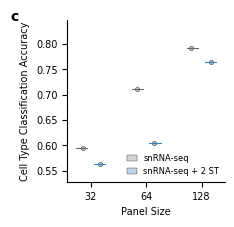

In [8]:
figure, axis = plt.subplots(figsize=(2.25, 2.25), facecolor="white")
accuracy = results[["training_seed", "panel", "panel_size", "cell_type_accuracy"]]
_draw_violin_panel(axis, accuracy, "cell_type_accuracy", "Cell Type Classification Accuracy", show_legend=True, rng_seed=17)
figure.text(0.015, 0.985, "c", ha="left", va="top", fontsize=10, weight="bold")
figure.subplots_adjust(left=0.27, right=0.97, bottom=0.22, top=0.94)
display(figure)
plt.close(figure)

### Figure 6d: MERFISH expression support

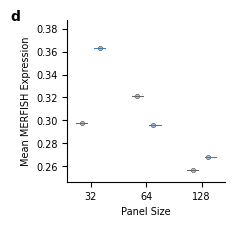

In [9]:
figure, axis = plt.subplots(figsize=(2.25, 2.25), facecolor="white")
expression_values = results[["training_seed", "panel", "panel_size", "mean_merfish_expression"]]
_draw_violin_panel(axis, expression_values, "mean_merfish_expression", "Mean MERFISH Expression", show_legend=False, rng_seed=23)
figure.text(0.015, 0.985, "d", ha="left", va="top", fontsize=10, weight="bold")
figure.subplots_adjust(left=0.27, right=0.97, bottom=0.22, top=0.94)
display(figure)
plt.close(figure)

## Figure 6f: package-level probe feasibility

The external ODT and OligoMiner screens take hours and are not rerun in this hosted notebook. This cell visualizes the completed 12,160-gene manuscript backend summary. These values are explicitly treated as a reference output, not as a result generated by the current notebook run.

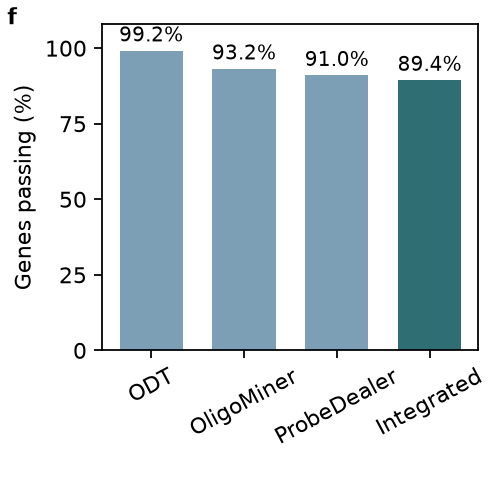

In [10]:
probe_reference_root = ROOT / "reproducibility/reference_outputs"
gate_summary = pd.read_csv(probe_reference_root / "agent_full_tool_pass_summary.tsv", sep="\t")
gate_names = {
    "ODT_property_ge20": "ODT",
    "OligoMiner_geneaware_specific_ge10": "OligoMiner",
    "ProbeDealer_target_final_ge20": "ProbeDealer",
    "three_tool_feasibility": "Integrated",
}
pass_rates = gate_summary.loc[gate_summary["gate"].isin(gate_names)].copy()
pass_rates["tool"] = pass_rates["gate"].map(gate_names)
pass_rates["pass_percent"] = pass_rates["pass_count"] / pass_rates["total_count"] * 100
pass_rates["tool"] = pd.Categorical(pass_rates["tool"], list(gate_names.values()), ordered=True)
pass_rates = pass_rates.sort_values("tool")
pass_rates.to_csv(FIGURE_DATA / "figure6_f_pass_rates.tsv", sep="\t", index=False)
figure, axis = plt.subplots(figsize=(3.05, 3.0), facecolor="white")
axis.bar(pass_rates["tool"], pass_rates["pass_percent"], color=["#7c9fb5", "#7c9fb5", "#7c9fb5", "#2f6f73"], width=0.68)
for index, value in enumerate(pass_rates["pass_percent"]):
    axis.text(index, value + 1.5, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)
axis.set_ylabel("Genes passing (%)")
axis.set_ylim(0, 108)
axis.set_yticks([0, 25, 50, 75, 100])
axis.tick_params(axis="x", labelrotation=28)
figure.text(0.015, 0.985, "f", ha="left", va="top", fontsize=10, weight="bold")
figure.subplots_adjust(left=0.21, right=0.98, bottom=0.27, top=0.95)
display(figure)
plt.close(figure)

## Figure 6g: representative ProbeDealer off-target profiles

This cell visualizes the ten manuscript genes extracted from the completed 12,160-gene ProbeDealer scan on pc157. Each bar separates target-compatible probes, known different-symbol off-targets and probes whose annotation or transcriptome hit remains unknown.

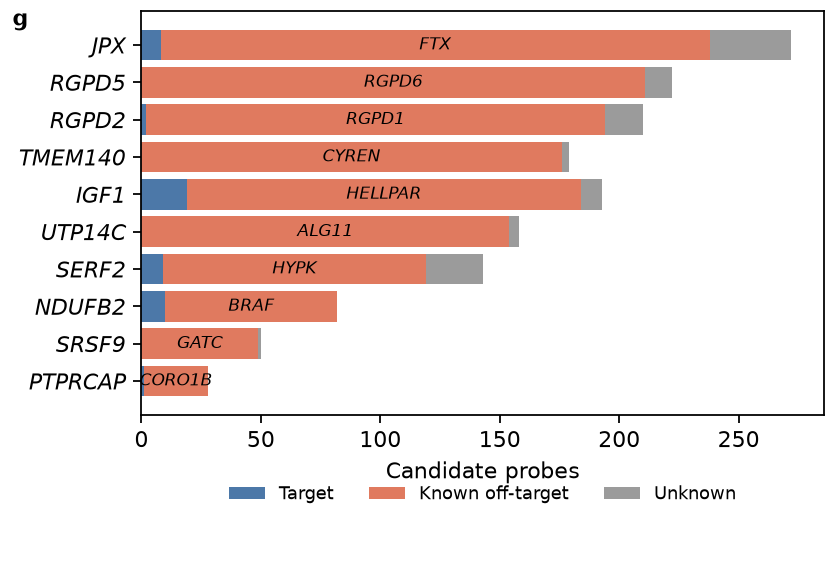

In [11]:
examples = pd.read_csv(
    probe_reference_root / "agent_probedealer_offtarget_examples.tsv", sep="\t"
).sort_values("example_order")
examples.to_csv(FIGURE_DATA / "figure6_g_offtarget_examples.tsv", sep="\t", index=False)
figure, axis = plt.subplots(figsize=(5.2, 3.55), facecolor="white")
y = np.arange(len(examples))
target = examples["target_compatible"].to_numpy(float)
offtarget = examples["known_offtarget"].to_numpy(float)
unknown = examples["unknown"].to_numpy(float)
axis.barh(y, target, color="#4c78a8", height=0.82, label="Target")
axis.barh(y, offtarget, left=target, color="#e07a5f", height=0.82, label="Known off-target")
axis.barh(y, unknown, left=target + offtarget, color="#9b9b9b", height=0.82, label="Unknown")
for yi, left, width, symbol in zip(y, target, offtarget, examples["offtarget_symbol"], strict=True):
    if symbol and width > 0:
        axis.text(left + width / 2, yi, symbol, ha="center", va="center", fontsize=7.5, fontstyle="italic")
axis.set_yticks(y)
axis.set_yticklabels(examples["gene_symbol"], fontstyle="italic")
axis.invert_yaxis()
axis.set_xlabel("Candidate probes")
axis.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.26), ncol=3, fontsize=8)
figure.text(0.015, 0.985, "g", ha="left", va="top", fontsize=10, weight="bold")
figure.subplots_adjust(left=0.17, right=0.99, top=0.98, bottom=0.27)
display(figure)
plt.close(figure)

## Record the run

The manifest is written after the analysis and is never read as an analysis input.

In [ ]:
_ = write_json(CASE_OUTPUT / "run_manifest.json", {
    "workflow": "05_agent", "inputs": relative_inputs,
    "configuration": {"epochs": EPOCHS, "device": DEVICE, "panel_sizes": [32, 64, 128], "source_weights": [0.25, 0.5, 0.75]},
    "agent_plan": agent_plan,
    "outputs": {
        "figure6_c_d": str(FIGURE_DATA / "figure6_c_d_values.tsv"),
        "figure6_f": str(FIGURE_DATA / "figure6_f_pass_rates.tsv"),
        "figure6_g": str(FIGURE_DATA / "figure6_g_offtarget_examples.tsv"),
        "tuning": str(FIGURE_DATA / "agent_parameter_tuning.tsv"),
    },
    "probe_backend": {
        "status": "reference_output",
        "scope": "manuscript_figure6_f_g",
        "artifacts": {
            "pass_rates": str(probe_reference_root / "agent_full_tool_pass_summary.tsv"),
            "offtarget_examples": str(probe_reference_root / "agent_probedealer_offtarget_examples.tsv"),
        },
    },
})

## Full manuscript command

The CLI runs all five spatial references and repeated seeds. Add `--run-probe-feasibility` to run Figure 6f-g from the complete candidate universe after configuring the human transcriptome index and external backends:

```bash
python reproducibility/workflows/agent/run_tutorial.py --data-root data/tutorials --output-dir outputs/paper/agent --panel-sizes 32,64,128 --training-seeds 1,2,3,4,5 --run-probe-feasibility
```

For a separate model-level hyperparameter example, the repository also provides a Pareto-guided search over SMITH task, dropout, regularization, sigma and learning-rate settings:

```bash
python scripts/agent_examples/run_liver_pareto_hpo.py \
  --source-adata data/tutorials/agent/liver_merfish/adata_healthy_nucseq.h5ad \
  --merfish-adata data/tutorials/agent/liver_merfish/adata_healthy_merfish.h5ad \
  --output-dir outputs/tutorials/agent_hpo \
  --panel-size 64 --max-iterations 2 --max-new-trials-per-iteration 8
```

This optional search is not required for the hosted Figure 6c-d and 6f-g run.